100%|██████████| 170M/170M [00:02<00:00, 66.5MB/s]


Epoch [1/10], Loss: 1.2861, Test Loss: 1.0122, Accuracy: 64.31%
Epoch [2/10], Loss: 0.9202, Test Loss: 0.9171, Accuracy: 67.98%
Epoch [3/10], Loss: 0.7689, Test Loss: 0.9005, Accuracy: 69.08%
Epoch [4/10], Loss: 0.6589, Test Loss: 0.8216, Accuracy: 72.18%
Epoch [5/10], Loss: 0.5610, Test Loss: 0.8788, Accuracy: 71.25%
Epoch [6/10], Loss: 0.4748, Test Loss: 0.8933, Accuracy: 71.88%
Epoch [7/10], Loss: 0.3968, Test Loss: 0.9427, Accuracy: 71.85%
Epoch [8/10], Loss: 0.3328, Test Loss: 1.0769, Accuracy: 71.20%
Epoch [9/10], Loss: 0.2711, Test Loss: 1.1569, Accuracy: 70.60%
Epoch [10/10], Loss: 0.2263, Test Loss: 1.2784, Accuracy: 70.41%


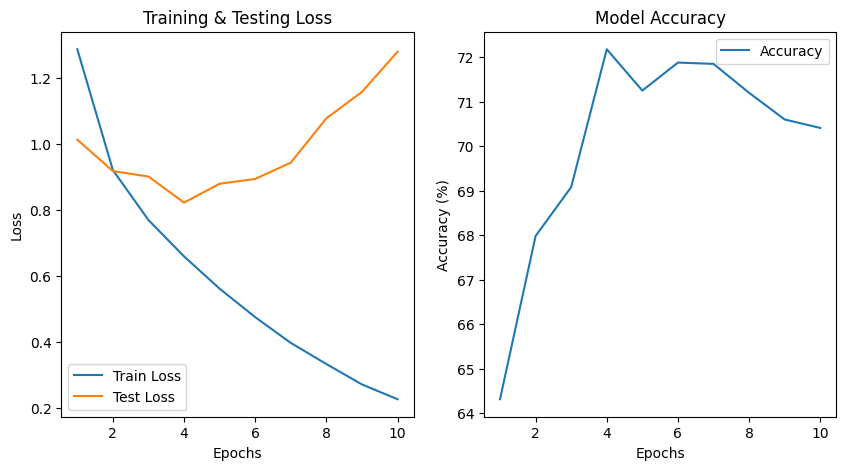

Final Accuracy: 70.41%


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

# Device configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Data preparation (CIFAR-10 dataset)
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=32, shuffle=True)

testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)
testloader = torch.utils.data.DataLoader(testset, batch_size=32, shuffle=False)

# CNN Model Definition
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, stride=1, padding=1)
        self.relu = nn.ReLU()
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2, padding=0)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1)
        self.fc1 = nn.Linear(64 * 8 * 8, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x)))
        x = self.pool(self.relu(self.conv2(x)))
        x = x.view(-1, 64 * 8 * 8)
        x = self.relu(self.fc1(x))
        x = self.fc2(x)
        return x

# Model, Loss Function, Optimizer
model = CNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Training
num_epochs = 10
train_losses = []
test_losses = []
accuracy_list = []

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    for images, labels in trainloader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    train_losses.append(running_loss / len(trainloader))

    # Testing
    model.eval()
    correct = 0
    total = 0
    test_loss = 0.0
    with torch.no_grad():
        for images, labels in testloader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            test_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    test_losses.append(test_loss / len(testloader))
    accuracy = 100 * correct / total
    accuracy_list.append(accuracy)

    print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {running_loss / len(trainloader):.4f}, Test Loss: {test_loss / len(testloader):.4f}, Accuracy: {accuracy:.2f}%')

# Plot Loss and Accuracy
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.plot(range(1, num_epochs+1), train_losses, label='Train Loss')
plt.plot(range(1, num_epochs+1), test_losses, label='Test Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Training & Testing Loss')

plt.subplot(1,2,2)
plt.plot(range(1, num_epochs+1), accuracy_list, label='Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.title('Model Accuracy')
plt.show()

print(f'Final Accuracy: {accuracy_list[-1]:.2f}%')

Files already downloaded and verified
Files already downloaded and verified
Epoch [1/30], Loss: 1.2791, Test Loss: 1.0078, Accuracy: 64.44%
Epoch [2/30], Loss: 0.9038, Test Loss: 0.8883, Accuracy: 68.62%
Epoch [3/30], Loss: 0.7510, Test Loss: 0.8432, Accuracy: 71.02%
Epoch [4/30], Loss: 0.6315, Test Loss: 0.8110, Accuracy: 72.23%
Epoch [5/30], Loss: 0.5327, Test Loss: 0.8222, Accuracy: 72.60%
Epoch [6/30], Loss: 0.4433, Test Loss: 0.8982, Accuracy: 71.83%
Epoch [7/30], Loss: 0.3623, Test Loss: 0.9897, Accuracy: 71.04%
Epoch [8/30], Loss: 0.2910, Test Loss: 1.0821, Accuracy: 71.66%
Epoch [9/30], Loss: 0.2298, Test Loss: 1.1823, Accuracy: 71.58%
Epoch [10/30], Loss: 0.1857, Test Loss: 1.3407, Accuracy: 71.09%
Epoch [11/30], Loss: 0.1516, Test Loss: 1.4751, Accuracy: 70.44%
Epoch [12/30], Loss: 0.1316, Test Loss: 1.5755, Accuracy: 70.77%
Epoch [13/30], Loss: 0.1113, Test Loss: 1.8022, Accuracy: 69.02%
Epoch [14/30], Loss: 0.1038, Test Loss: 1.8778, Accuracy: 70.24%
Epoch [15/30], Loss: 0.

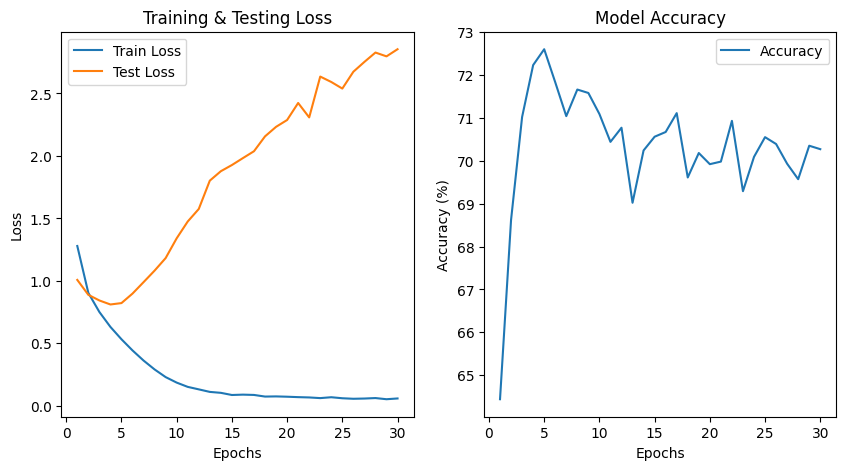

Final Accuracy: 70.27%


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

# Device configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Data preparation (CIFAR-10 dataset)
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=32, shuffle=True)

testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)
testloader = torch.utils.data.DataLoader(testset, batch_size=32, shuffle=False)

# CNN Model Definition
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, stride=1, padding=1)
        self.relu = nn.ReLU()
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2, padding=0)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1)
        self.fc1 = nn.Linear(64 * 8 * 8, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x)))
        x = self.pool(self.relu(self.conv2(x)))
        x = x.view(-1, 64 * 8 * 8)
        x = self.relu(self.fc1(x))
        x = self.fc2(x)
        return x

# Model, Loss Function, Optimizer
model = CNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Training with 30 Epochs
num_epochs = 30
train_losses = []
test_losses = []
accuracy_list = []

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    for images, labels in trainloader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    train_losses.append(running_loss / len(trainloader))

    # Testing
    model.eval()
    correct = 0
    total = 0
    test_loss = 0.0
    with torch.no_grad():
        for images, labels in testloader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            test_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    test_losses.append(test_loss / len(testloader))
    accuracy = 100 * correct / total
    accuracy_list.append(accuracy)

    print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {running_loss / len(trainloader):.4f}, Test Loss: {test_loss / len(testloader):.4f}, Accuracy: {accuracy:.2f}%')

# Plot Loss and Accuracy
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.plot(range(1, num_epochs+1), train_losses, label='Train Loss')
plt.plot(range(1, num_epochs+1), test_losses, label='Test Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Training & Testing Loss')

plt.subplot(1,2,2)
plt.plot(range(1, num_epochs+1), accuracy_list, label='Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.title('Model Accuracy')
plt.show()

print(f'Final Accuracy: {accuracy_list[-1]:.2f}%')